In [14]:
# Install required packages
!pip install numpy==1.24.4
!pip install surprise
!pip install matplotlib


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [16]:
import pandas as pd
# from google.colab import drive
from ast import literal_eval
import matplotlib.pyplot as plt
import numpy as np
import re
import spacy
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# drive.mount('/content/drive')


In [17]:
from surprise import Dataset, Reader, SVD


# Load data

- Nguồn: https://www.kaggle.com/datasets/rounakbanik/the-movies-**dataset**

In [26]:
"""Tệp siêu dữ liệu phim chính.
Chứa thông tin về 45.000 phim có trong bộ dữ liệu Full MovieLens. """

file_path = '/content/drive/MyDrive/ML03/movielen'
metadata = pd.read_csv(f'./data/recommendation_data/movies_metadata.csv')
print(f'Số lượng phim: {len(metadata.index)}')

Số lượng phim: 45466


/var/folders/1q/wjq2r3894rs3kpl_ld441jsh0000gn/T/ipykernel_40164/3100546316.py:5: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(f'./data/recommendation_data/movies_metadata.csv')


In [27]:
metadata.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [28]:
metadata.head(1)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0


In [30]:
"""links_small.csv: Chứa ID TMDB và IMDB của một tập hợp con nhỏ gồm 9.000 phim của Bộ dữ liệu đầy đủ.
The Movie Database (TMDB) is a popular, user editable database for movies and TV shows."""
links_small = pd.read_csv(f'./data/recommendation_data/links_small.csv')
links_small.tail(5)

,movieId,imdbId,tmdbId
9120,162672,3859980,402672.0
9121,163056,4262980,315011.0
9122,163949,2531318,391698.0
9123,164977,27660,137608.0
9124,164979,3447228,410803.0


In [31]:
links_small = links_small[links_small['tmdbId'].notnull()]['tmdbId'].astype('int')
len(links_small)

9112

In [32]:
metadata.iloc[[19730, 29503, 35587]]['id']

19730    1997-08-20
29503    2012-09-29
35587    2014-01-01
Name: id, dtype: object

In [33]:
# metadata = metadata.drop([19730, 29503, 35587]) # bỏ đi 1 số dòng có id sai format
# metadata['id'] = metadata['id'].astype('int')

metadata['id'] = pd.to_numeric(metadata['id'], errors='coerce', downcast='integer')
metadata = metadata.dropna(subset=['id']).astype({'id': 'int'})

# chuyển cột sang định dạng số (interger), nếu dòng đó không chuyển được sang dạng số, chuyển thành NaN

# chỉ lấy tập con của metadata
metadata = metadata[metadata['id'].isin(links_small)]
metadata.shape

(9099, 24)

In [35]:
metadata.head(1)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0


In [36]:
print(metadata.columns)

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')


In [37]:
metadata['genres'].iloc[0]

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

In [39]:
"""keywords.csv: Chứa các từ khóa cốt truyện phim cho phim MovieLens .
credit.csv: Bao gồm Thông tin về diễn viên và đoàn làm phim cho tất cả các bộ phim
 """
credits = pd.read_csv(f'./data/recommendation_data/credits.csv')
keywords = pd.read_csv(f'./data/recommendation_data/keywords.csv')


In [40]:
keywords['id'] = keywords['id'].astype('int')
credits['id'] = credits['id'].astype('int')
metadata['id'] = metadata['id'].astype('int')

metadata = metadata.merge(credits, on='id')
metadata = metadata.merge(keywords, on='id')

In [41]:
metadata.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count', 'cast', 'crew', 'keywords'],
      dtype='object')

In [42]:
metadata['keywords'].iloc[0]

"[{'id': 931, 'name': 'jealousy'}, {'id': 4290, 'name': 'toy'}, {'id': 5202, 'name': 'boy'}, {'id': 6054, 'name': 'friendship'}, {'id': 9713, 'name': 'friends'}, {'id': 9823, 'name': 'rivalry'}, {'id': 165503, 'name': 'boy next door'}, {'id': 170722, 'name': 'new toy'}, {'id': 187065, 'name': 'toy comes to life'}]"

In [44]:
ratings = pd.read_csv(f'./data/recommendation_data/ratings_small.csv')
#The subset of 100,000 ratings from 700 users on 9,000 movies.
ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1.260759e+09
1,1,1029,3.0,1.260759e+09
2,1,1061,3.0,1.260759e+09
3,1,1129,2.0,1.260759e+09
4,1,1172,4.0,1.260759e+09


In [45]:
ratings.userId.value_counts()

547       2391
564       1868
624       1735
15        1700
73        1610
          ... 
498         20
540         20
583         20
164980       9
164982       3
Name: userId, Length: 673, dtype: int64

# Data Preparation

In [46]:
metadata_small = metadata[['genres', 'id', 'overview', 'popularity',
                           'production_companies', 'spoken_languages', 'title',
                           'vote_average', 'vote_count' ,'cast', 'crew', 'keywords']]
metadata_small.head(1)

,genres,id,overview,popularity,production_companies,spoken_languages,title,vote_average,vote_count,cast,crew,keywords
0,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",862,"Led by Woody, Andy's toys live happily in his ...",21.946943,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_639_1': 'en', 'name': 'English'}]",Toy Story,7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."


In [47]:
numeric_cols = metadata_small.select_dtypes(include=['number']).columns.tolist()
categorical_cols = metadata_small.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Biến số:", numeric_cols)
print("Biến phân loại:", categorical_cols)

Biến số: ['id', 'vote_average', 'vote_count']
Biến phân loại: ['genres', 'overview', 'popularity', 'production_companies', 'spoken_languages', 'title', 'cast', 'crew', 'keywords']


In [48]:
metadata_small['popularity'] = metadata_small['popularity'].astype('float')

/var/folders/1q/wjq2r3894rs3kpl_ld441jsh0000gn/T/ipykernel_40164/792145421.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata_small['popularity'] = metadata_small['popularity'].astype('float')


In [49]:
genres = metadata_small['genres'].iloc[0]
genres

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

In [50]:
cast_list = metadata_small['cast'].iloc[10]
cast_list

'[{\'cast_id\': 1, \'character\': \'Andrew Shepherd\', \'credit_id\': \'52fe44dac3a36847f80adf79\', \'gender\': 2, \'id\': 3392, \'name\': \'Michael Douglas\', \'order\': 0, \'profile_path\': \'/nmlitv4g2jXO3sJrnA9g980j2uc.jpg\'}, {\'cast_id\': 2, \'character\': \'Sydney Ellen Wade\', \'credit_id\': \'52fe44dac3a36847f80adf7d\', \'gender\': 1, \'id\': 516, \'name\': \'Annette Bening\', \'order\': 1, \'profile_path\': \'/q8pCSQzGLrhgtVXBKzMnwfoeBlH.jpg\'}, {\'cast_id\': 3, \'character\': \'Lewis Rothschild\', \'credit_id\': \'52fe44dac3a36847f80adf81\', \'gender\': 2, \'id\': 521, \'name\': \'Michael J. Fox\', \'order\': 2, \'profile_path\': \'/aeN1cA04vVXKrVy1SuS1JOhABBs.jpg\'}, {\'cast_id\': 4, \'character\': \'A.J. MacInerney\', \'credit_id\': \'52fe44dac3a36847f80adf85\', \'gender\': 2, \'id\': 8349, \'name\': \'Martin Sheen\', \'order\': 3, \'profile_path\': \'/ve77Q75moQhoB6cxdMfigfrHeTA.jpg\'}, {\'cast_id\': 11, \'character\': \'Robin McCall\', \'credit_id\': \'52fe44dac3a36847f8

In [51]:
genres_list = literal_eval(genres)
for genre in genres_list:
  print(genre['name'])

Animation
Comedy
Family


In [52]:
[genre['name'] for genre in literal_eval(genres)][:5]

['Animation', 'Comedy', 'Family']

In [53]:
[cast['name'] for cast in literal_eval(cast_list)][:3]

['Michael Douglas', 'Annette Bening', 'Michael J. Fox']

In [54]:
features = ['crew', 'cast', 'keywords', 'genres', 'production_companies', 'spoken_languages']
for feature in features:
    metadata_small[feature] = metadata_small[feature].apply(literal_eval)


/var/folders/1q/wjq2r3894rs3kpl_ld441jsh0000gn/T/ipykernel_40164/3624788524.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata_small[feature] = metadata_small[feature].apply(literal_eval)


In [55]:
def get_director(x):
    for i in x:
        if i['job'] == 'Director':
            return i['name']
    return np.nan

In [56]:
def get_list(x): # return list feature chứa tên diễn viên, key words của bộ phim, đội ngũ làm phim, thể loại phim,...
    if isinstance(x, list): #Kiểm tra xem x có phải là một danh sách không
        names = [i['name'] for i in x]
        if len(names) > 5:
            names = names[:5]
        return names

    return []

In [57]:
metadata_small['director'] = metadata_small['crew'].apply(get_director)

features = ['cast', 'keywords', 'genres', 'production_companies', 'spoken_languages']
for feature in features:
    metadata_small[feature] = metadata_small[feature].apply(get_list)

/var/folders/1q/wjq2r3894rs3kpl_ld441jsh0000gn/T/ipykernel_40164/2010479927.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata_small['director'] = metadata_small['crew'].apply(get_director)
/var/folders/1q/wjq2r3894rs3kpl_ld441jsh0000gn/T/ipykernel_40164/2010479927.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata_small[feature] = metadata_small[feature].apply(get_list)


In [58]:
metadata_small = metadata_small.drop(columns='crew')
metadata_small.iloc[100]

genres                                      [Action, Drama, History, War]
id                                                                    197
overview                Enraged at the slaughter of Murron, his new br...
popularity                                                      20.755149
production_companies    [Icon Entertainment International, The Ladd Co...
spoken_languages                             [English, Français, Latin, ]
title                                                          Braveheart
vote_average                                                          7.7
vote_count                                                         3404.0
cast                    [Mel Gibson, Catherine McCormack, Sophie Marce...
keywords                [individual, scotland, in love with enemy, leg...
director                                                       Mel Gibson
Name: 100, dtype: object

In [59]:
metadata_small['rating'] = (metadata_small['vote_average'] * metadata_small['popularity']) / metadata_small['popularity'].mean()
metadata_small['rating_class'] =  pd.qcut(metadata_small['rating'], q=[0, 0.3, 0.6, 1.0], labels=['low', 'medium', 'high'])
metadata_small['rating_class'].value_counts()

high      3688
low       2766
medium    2765
Name: rating_class, dtype: int64



```
# This is formatted as code
```

# Cosine similarity

In [60]:
metadata_small.columns

Index(['genres', 'id', 'overview', 'popularity', 'production_companies',
       'spoken_languages', 'title', 'vote_average', 'vote_count', 'cast',
       'keywords', 'director', 'rating', 'rating_class'],
      dtype='object')

In [61]:
df = metadata_small.copy()
df.head()

,genres,id,overview,popularity,production_companies,spoken_languages,title,vote_average,vote_count,cast,keywords,director,rating,rating_class
0,"[Animation, Comedy, Family]",862,"Led by Woody, Andy's toys live happily in his ...",21.946943,[Pixar Animation Studios],[English],Toy Story,7.7,5415.0,"[Tom Hanks, Tim Allen, Don Rickles, Jim Varney...","[jealousy, toy, boy, friendship, friends]",John Lasseter,23.344056,high
1,"[Adventure, Fantasy, Family]",8844,When siblings Judy and Peter discover an encha...,17.015539,"[TriStar Pictures, Teitler Film, Interscope Co...","[English, Français]",Jumanji,6.9,2413.0,"[Robin Williams, Jonathan Hyde, Kirsten Dunst,...","[board game, disappearance, based on children'...",Joe Johnston,16.218339,high
2,"[Romance, Comedy]",15602,A family wedding reignites the ancient feud be...,11.712900,"[Warner Bros., Lancaster Gate]",[English],Grumpier Old Men,6.5,92.0,"[Walter Matthau, Jack Lemmon, Ann-Margret, Sop...","[fishing, best friend, duringcreditsstinger, o...",Howard Deutch,10.516939,high
3,"[Comedy, Drama, Romance]",31357,"Cheated on, mistreated and stepped on, the wom...",3.859495,[Twentieth Century Fox Film Corporation],[English],Waiting to Exhale,6.1,34.0,"[Whitney Houston, Angela Bassett, Loretta Devi...","[based on novel, interracial relationship, sin...",Forest Whitaker,3.252160,medium
4,[Comedy],11862,Just when George Banks has recovered from his ...,8.387519,"[Sandollar Productions, Touchstone Pictures]",[English],Father of the Bride Part II,5.7,173.0,"[Steve Martin, Diane Keaton, Martin Short, Kim...","[baby, midlife crisis, confidence, aging, daug...",Charles Shyer,6.604196,medium


In [62]:
# Load spaCy English model
nlp = spacy.load("en_core_web_sm")

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()

    # Remove special characters & punctuation
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # Apply spaCy pipeline
    doc = nlp(text)

    # Lemmatize + remove stopwords + remove spaces
    tokens = [
        token.lemma_
        for token in doc
        if token.lemma_ not in ENGLISH_STOP_WORDS and not token.is_space
    ]

    return ' '.join(tokens)

def create_movie_profile(row):
    genres = ' '.join(row['genres']) if isinstance(row['genres'], list) else ''
    keywords = ' '.join(row['keywords']) if isinstance(row['keywords'], list) else ''
    overview = row['overview'] if isinstance(row['overview'], str) else ''
    cast = ' '.join(row['cast']) if isinstance(row['cast'], list) else ''
    production_companies = ' '.join(row['production_companies']) if isinstance(row['production_companies'], list) else ''
    spoken_languages = ' '.join(row['spoken_languages']) if isinstance(row['spoken_languages'], list) else ''
    director = row['director'] if isinstance(row['director'], str) else ''
    rating_class = row['rating_class'] if isinstance(row['rating_class'], str) else ''
    return f"{genres} {overview} {keywords} {cast} {production_companies} {spoken_languages} {director} {rating_class}"

df['movie_profile'] = df.apply(create_movie_profile, axis=1)
df['movie_profile'][0]

"Animation Comedy Family Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences. jealousy toy boy friendship friends Tom Hanks Tim Allen Don Rickles Jim Varney Wallace Shawn Pixar Animation Studios English John Lasseter high"

In [63]:
df['movie_profile'] = df['movie_profile'].apply(clean_text)
df['movie_profile'][0]

'animation comedy family lead woody andys toy live happily room andys birthday bring buzz lightyear scene afraid lose place andys heart woody plot buzz circumstance separate buzz woody owner duo eventually learn aside difference jealousy toy boy friendship friend tom hanks tim allen don rickles jim varney wallace shawn pixar animation studio english john lasseter high'

In [64]:
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['movie_profile'])

# Biến đầu vào thành vector
user_query = "Today I want to watch animation about friendships"
user_query = clean_text(user_query)
user_vec = vectorizer.transform([user_query])
user_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (1, 44643)>

In [65]:
from sklearn.metrics.pairwise import cosine_similarity

cos_sim = cosine_similarity(user_vec, tfidf_matrix).flatten()

# Lấy top N phim
top_n = 20
top_indices = cos_sim.argsort()[-top_n:][::-1]

recommended_movies = df.iloc[top_indices][['title', 'vote_average',
                                           'genres','spoken_languages','keywords']]
recommended_movies

,title,vote_average,genres,spoken_languages,keywords
35,Across the Sea of Time,3.5,"[Adventure, History, Drama, Family]","[Pусский, English]",[]
2751,Creature Comforts,7.3,"[Animation, Comedy, Family]","[English, Deutsch]",[animation]
3981,Return to Never Land,6.1,"[Adventure, Fantasy, Animation, Family]",[English],[animation]
7794,Day & Night,7.6,"[Animation, Family]",[],"[short, pixar animation]"
7589,Death at a Funeral,5.5,[Comedy],[English],"[remake, family relationships]"
8334,"Batman: The Dark Knight Returns, Part 2",7.9,"[Action, Animation]",[English],"[dc comics, future, joker, robin, based on gra..."
8065,The Intouchables,8.2,"[Drama, Comedy]","[English, Français]","[male friendship, masseuse, friendship, aristo..."
8423,Monsters University,7.0,"[Animation, Family]",[English],"[monster, dormitory, games, animation, best fr..."
5456,Garfield,5.2,"[Animation, Comedy, Family]",[English],"[competition, moderator, lasagne, garfield]"
6546,Mrs Palfrey at The Claremont,6.8,"[Comedy, Drama]",[English],"[poetry, friendship, memory]"


# Colaborative

In [66]:
ratings = pd.read_csv(f'./data/recommendation_data/ratings_small.csv')
ratings = ratings.drop(columns=['timestamp'])
#The subset of 100,000 ratings from 700 users on 9,000 movies.
ratings.tail()

,userId,movieId,rating
100011,164980,74228,5.0
100012,164980,98124,3.0
100013,164982,1,4.0
100014,164982,2,3.0
100015,164982,4,5.0


<Axes: ylabel='Frequency'>

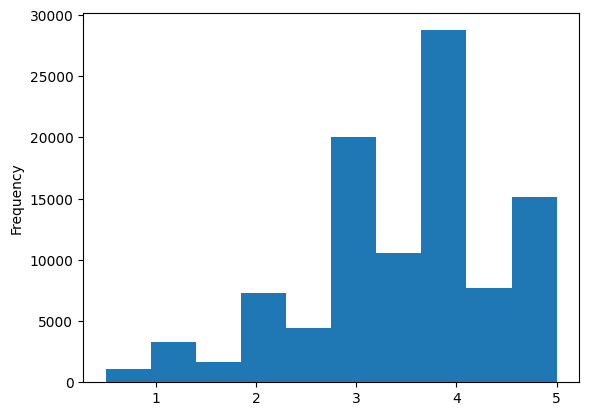

In [67]:
ratings['rating'].plot(kind='hist')

In [68]:
# Giả sử người dùng mới là userId = 9999
new_user_ratings = pd.DataFrame([
    {'userId': 9999, 'movieId': 1172, 'rating': 5.0},
    {'userId': 9999, 'movieId': 1061, 'rating': 4.5},
    {'userId': 9999, 'movieId': 1029, 'rating': 4.0},
])

ratings = pd.concat([ratings, new_user_ratings], ignore_index=True)
ratings.tail()


,userId,movieId,rating
100014,164982,2,3.0
100015,164982,4,5.0
100016,9999,1172,5.0
100017,9999,1061,4.5
100018,9999,1029,4.0


In [20]:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

trainset = data.build_full_trainset()

# Huấn luyện SVD model
svd_model = SVD()
svd_model.fit(trainset)


In [69]:
# Lấy top phim từ content-based recommendation
cb_recommended_ids = df.iloc[top_indices]['id'].tolist()  # hoặc df['movieId'] nếu khớp với `ratings`

# Dự đoán rating với các phim này
svd_preds = []
for movie_id in cb_recommended_ids:
    pred = svd_model.predict(uid=164982, iid=movie_id)
    svd_preds.append((movie_id, pred.est))

# Sắp xếp theo dự đoán
svd_preds.sort(key=lambda x: x[1], reverse=True)

# Lấy top 5 phim gợi ý cuối cùng
top_5_final = [movie_id for movie_id, _ in svd_preds[:5]]
final_recommendations = df[df['id'].isin(top_5_final)][['title', 'vote_average', 'genres']]
final_recommendations

,title,vote_average,genres
35,Across the Sea of Time,3.5,"[Adventure, History, Drama, Family]"
2751,Creature Comforts,7.3,"[Animation, Comedy, Family]"
3981,Return to Never Land,6.1,"[Adventure, Fantasy, Animation, Family]"
7589,Death at a Funeral,5.5,[Comedy]
7794,Day & Night,7.6,"[Animation, Family]"
